In [10]:
import numpy as np
import json


def read_npz_file(dir: str):
    import numpy as np
    data = np.load(dir)
    return dict(data)

def check_episode_idx_and_group_episode_name(query_episode_idx, group_name, episode_name):
    # Load the mapping from episode index to folder
    with open('ep_idxs_to_fol.json', 'r') as f:
        ep_idx_to_fol = json.load(f)

    # Convert query_episode_idx to string for lookup
    query_episode_idx_str = str(query_episode_idx)

    # Get the folder path for this episode index
    folder_path = ep_idx_to_fol.get(query_episode_idx_str, None)

    if folder_path is None:
        print(f"Episode index {query_episode_idx_str} not found in ep_idxs_to_fol.json")
        return

    # Extract the group name and episode name from the folder path
    # folder_path is expected to be like: ricl_human_demo/2025_08_29_sprinkles_to_coke_robot/Fri_Aug_29_07_03_24_2025
    path_parts = folder_path.split('/')
    if len(path_parts) < 3:
        print(f"Malformed folder_path: {folder_path}")
        return

    folder_group_name = path_parts[1]
    folder_episode_name = path_parts[2]

    group_match = (folder_group_name == group_name)
    episode_match = (folder_episode_name == episode_name)

    if group_match and episode_match:
        print("MATCH: Both group_name and episode_name match the mapping for query_episode_idx.")
    elif group_match and not episode_match:
        print("PARTIAL MATCH: group_name matches but episode_name does NOT match the mapping for query_episode_idx.")
    elif not group_match and episode_match:
        print("PARTIAL MATCH: episode_name matches but group_name does NOT match the mapping for query_episode_idx.")
    else:
        print("MISMATCH: Neither group_name nor episode_name match the mapping for query_episode_idx.")


def visualize_query_and_retrieval(query_episode_idx, query_step_idx, camera_key='top_image', neighbor_rank=0):
    """Visualize a query frame and its retrieved neighbor.

    Args:
        query_episode_idx (int): Global episode id (from JSON mappings)
        query_step_idx (int): Step index within the query episode
        camera_key (str): One of {'top_image','wrist_image','right_image'}; fallback if missing
        neighbor_rank (int): Which neighbor to visualize (0 = top-1)
    Returns:
        tuple[int, int]: (retrieved_episode_idx, retrieved_step_idx)
    """
    import os
    import matplotlib.pyplot as plt

    # Load mapping from episode index to episode folder
    with open('ep_idxs_to_fol.json', 'r') as f:
        ep_idx_to_fol = json.load(f)

    def to_local_episode_dir(mapped_path: str) -> str:
        # mapped_path like: 'ricl_human_demo/<group>/<episode>'
        parts = mapped_path.split('/')
        if len(parts) >= 3:
            # In this notebook, CWD is preprocessing/<dataset>, so drop the dataset prefix
            return os.path.join('.', parts[1], parts[2])
        return mapped_path

    # Resolve query episode folder and load retrieval file
    q_folder_mapped = ep_idx_to_fol[str(int(query_episode_idx))]
    q_folder = to_local_episode_dir(q_folder_mapped)

    retrieval = read_npz_file(os.path.join(q_folder, 'indices_and_distances.npz'))
    retrieved_indices = retrieval['retrieved_indices']  # shape: [num_steps, K, 2]

    # Bounds check for step index
    if query_step_idx < 0 or query_step_idx >= retrieved_indices.shape[0]:
        max_idx = int(retrieved_indices.shape[0] - 1)
        print(f"query_step_idx {query_step_idx} out of range [0, {max_idx}]")
        return

    # Pick the first valid neighbor (skip any -1 rows if present)
    row = retrieved_indices[query_step_idx]
    valid = row[row[:, 0] != -1]
    if len(valid) == 0:
        print("No valid neighbors for this step.")
        return
    rank = min(max(0, int(neighbor_rank)), len(valid) - 1)
    retrieved_episode_idx, retrieved_step_idx = map(int, valid[rank])

    # Helper to fetch an image frame from processed_demo.npz
    def get_frame(ep_idx: int, step_idx: int, preferred_key: str):
        ep_folder_mapped = ep_idx_to_fol[str(int(ep_idx))]
        ep_folder = to_local_episode_dir(ep_folder_mapped)
        proc = read_npz_file(os.path.join(ep_folder, 'processed_demo.npz'))
        if preferred_key in proc:
            return proc[preferred_key][step_idx]
        for fallback_key in ['top_image', 'wrist_image', 'right_image']:
            if fallback_key in proc:
                return proc[fallback_key][step_idx]
        raise KeyError(f"No image arrays found in processed_demo.npz for episode {ep_idx}")

    # Load images
    q_img = get_frame(query_episode_idx, query_step_idx, camera_key)
    r_img = get_frame(retrieved_episode_idx, retrieved_step_idx, camera_key)

    # Titles: show ids and brief folder names
    def short_name(ep_idx: int) -> str:
        p = ep_idx_to_fol[str(int(ep_idx))].split('/')
        return f"{p[1]}/{p[2]}" if len(p) >= 3 else ep_idx_to_fol[str(int(ep_idx))]

    # Plot side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(q_img)
    axes[0].set_title(f"Query: {short_name(query_episode_idx)}\nstep {query_step_idx}  cam={camera_key}")
    axes[0].axis('off')

    axes[1].imshow(r_img)
    axes[1].set_title(f"Retrieved (rank {rank+1}): {short_name(retrieved_episode_idx)}\nstep {retrieved_step_idx}  cam={camera_key}")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    return retrieved_episode_idx, retrieved_step_idx

MATCH: Both group_name and episode_name match the mapping for query_episode_idx.


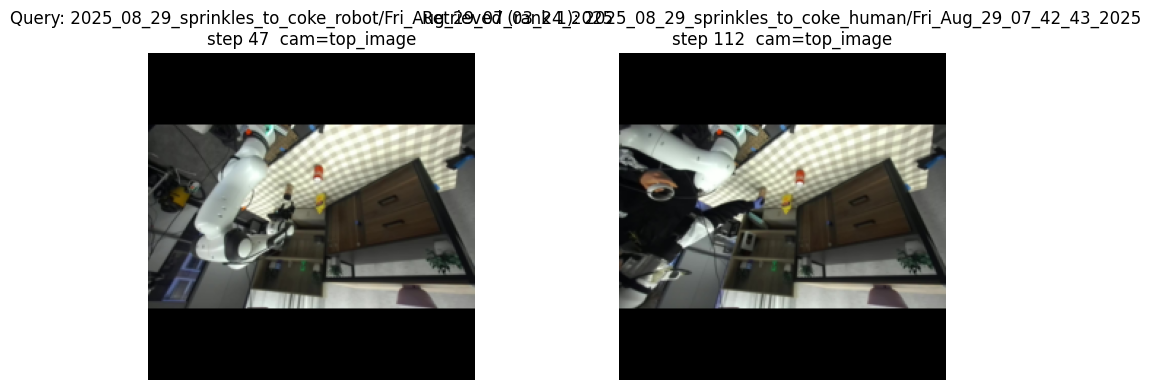

(100303, 112)

In [11]:
group_name = '2025_08_29_sprinkles_to_coke_robot'
episode_name = 'Fri_Aug_29_07_03_24_2025'

data = read_npz_file(f'./{group_name}/{episode_name}/indices_and_distances.npz')

query_episode_idx = data['query_indices'][0][0]
query_step_idx = np.random.randint(0, data['query_indices'].shape[0])

check_episode_idx_and_group_episode_name(query_episode_idx, group_name, episode_name)
visualize_query_and_retrieval(query_episode_idx, query_step_idx)